# Exploratory Data Analysis

### Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Graph Style Definition

In [62]:
sns.set_style("whitegrid")
sns.set_palette('viridis', n_colors=7)

### Data Loading

In [35]:
demo = pd.read_sas("DEMO_L.xpt")
biochem = pd.read_sas("BIOPRO_L.xpt")
trigly = pd.read_sas("TRIGLY_L.xpt")
chol_h = pd.read_sas("HDL_L.xpt")
tst = pd.read_sas("TST_L.xpt")

### Tables Used and Variables Chosen to Observe
- Demographic Variables and Sample Weights -> `DEMO_L.xpt` -> `demo`
    - [RIAGENDR - Gender](https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/DEMO_L.htm#RIAGENDR) -> `gender`
    - [RIDAGEYR - Age in years at screening](https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/DEMO_L.htm#RIDAGEYR) -> `age`
- Standard Biochemistry Profile -> `BIOPRO_L.xpt` -> `biochem`
    - [LBDSGLSI - Glucose, refrigerated serum (mmol/L)](https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/BIOPRO_L.htm#LBDSGLSI) -> `glu`
    - [LBDSTRSI - Triglycerides, refrig serum (mmol/L)](https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/BIOPRO_L.htm#LBDSTRSI) -> `tg_s` -> NOT USED????
- Cholesterol - Low-Density Lipoproteins (LDL) & Triglycerides -> `TRIGLY_L.xpt` -> `trigly`
    - [LBDTRSI - Triglyceride (mmol/L)](https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/TRIGLY_L.htm#LBDTRSI) -> `tg`
- Cholesterol – High-Density Lipoprotein (HDL_L) -> `HDL_L.xpt` -> `chol_h`
    - [LBDHDDSI - Direct HDL-Cholesterol (mmol/L)](https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/HDL_L.htm#LBDHDDSI) -> `hdl`
- Sex Steroid Hormone Panel - Serum -> `TST_L_Data.xpt` -> `tst`
    - [LBDESTSI - Estradiol (pmol/L)](https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/TST_L.htm#LBDESTSI) -> `estr`
    - [LBDTSTSI - Testosterone, total (nmol/L)](https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/TST_L.htm#LBDTSTSI) -> `tstn`
    - [LBXSHBG - SHBG (nmol/L)](https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/TST_L.htm#LBXSHBG) -> `shbg`
### Identifier Between the Tables -> `SEQN` -> `id`

# 1. Data Exploration and Cleaning
### Joining Tables

In [38]:
demo = demo[["SEQN", "RIAGENDR", "RIDAGEYR"]]
biochem = biochem[["SEQN", "LBDSGLSI"]]
trigly = trigly[["SEQN", "LBDTRSI"]]
chol_h = chol_h[["SEQN", "LBDHDDSI"]]
tst = tst[["SEQN", "LBDESTSI", "LBDTSTSI", "LBXSHBG"]]

df = (demo
      .merge(biochem, on="SEQN")
      .merge(trigly, on="SEQN")
      .merge(chol_h, on="SEQN")
      .merge(tst, on="SEQN")
)
df.head()

,SEQN,RIAGENDR,RIDAGEYR,LBDSGLSI,LBDTRSI,LBDHDDSI,LBDESTSI,LBDTSTSI,LBXSHBG
0,130378.0,1.0,43.0,6.0,1.727,1.16,89.5,23.200,23.94
1,130379.0,1.0,66.0,5.0,0.971,1.55,92.5,15.200,57.46
2,130380.0,2.0,44.0,8.0,4.234,1.27,312.0,0.479,52.01
3,130386.0,1.0,34.0,5.0,1.603,1.19,51.4,16.400,40.83
4,130394.0,1.0,51.0,5.0,0.644,1.24,71.6,18.100,38.05


In [ ]:
df = df.rename(columns={
    "SEQN": "id",
    "RIAGENDR": "gender",
    "RIDAGEYR": "age",
    "LBDSGLSI": "glu",
    "LBDTRSI": "tg",
    "LBDHDDSI": "hdl",
    "LBDESTSI": "estr",
    "LBDTSTSI": "tstn",
    "LBXSHBG": "shbg"
})
df.head()

,id,gender,age,glu,tg,hdl,estr,tstn,shbg
0,130378.0,1.0,43.0,6.0,1.727,1.16,89.5,23.200,23.94
1,130379.0,1.0,66.0,5.0,0.971,1.55,92.5,15.200,57.46
2,130380.0,2.0,44.0,8.0,4.234,1.27,312.0,0.479,52.01
3,130386.0,1.0,34.0,5.0,1.603,1.19,51.4,16.400,40.83
4,130394.0,1.0,51.0,5.0,0.644,1.24,71.6,18.100,38.05


In [44]:
numeric_columns = ['age', 'glu', 'tg', 'hdl', 'estr', 'tstn', 'shbg']
df[numeric_columns].describe().round()

,age,glu,tg,hdl,estr,tstn,shbg
count,3996.0,3527.0,3517.0,3546.0,3585.0,3589.0,3605.0
mean,49.0,6.0,1.0,1.0,247.0,8.0,53.0
std,21.0,2.0,1.0,0.0,1759.0,10.0,44.0
min,12.0,2.0,0.0,1.0,4.0,0.0,5.0
25%,31.0,5.0,1.0,1.0,32.0,1.0,29.0
50%,52.0,5.0,1.0,1.0,80.0,2.0,43.0
75%,66.0,6.0,2.0,2.0,133.0,15.0,64.0
max,80.0,50.0,20.0,4.0,45100.0,137.0,672.0


In [47]:
df[['id', 'gender', 'age']].astype(int)

,id,gender,age
0,130378,1,43
1,130379,1,66
2,130380,2,44
3,130386,1,34
4,130394,1,51
...,...,...,...
3991,142301,2,80
3992,142303,2,69
3993,142305,2,76
3994,142308,1,50


In [48]:
gender_dict = {1: 'male', 2: 'female'}
df['gender'].map(gender_dict)

0         male
1         male
2       female
3         male
4         male
         ...  
3991    female
3992    female
3993    female
3994      male
3995      male
Name: gender, Length: 3996, dtype: str

In [51]:
df.isna().sum()

id          0
gender      0
age         0
glu       469
tg        479
hdl       450
estr      411
tstn      407
shbg      391
dtype: int64

In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3996 entries, 0 to 3995
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      3996 non-null   float64
 1   gender  3996 non-null   float64
 2   age     3996 non-null   float64
 3   glu     3527 non-null   float64
 4   tg      3517 non-null   float64
 5   hdl     3546 non-null   float64
 6   estr    3585 non-null   float64
 7   tstn    3589 non-null   float64
 8   shbg    3605 non-null   float64
dtypes: float64(9)
memory usage: 281.1 KB


# 2. Hormones vs Age

**Research question**: How do hormonal values vary between individuals of different ages?

**We explore relationships between**:
- estradiol-age
- testosterone-age
- SHBG-age

Distribution of age data:

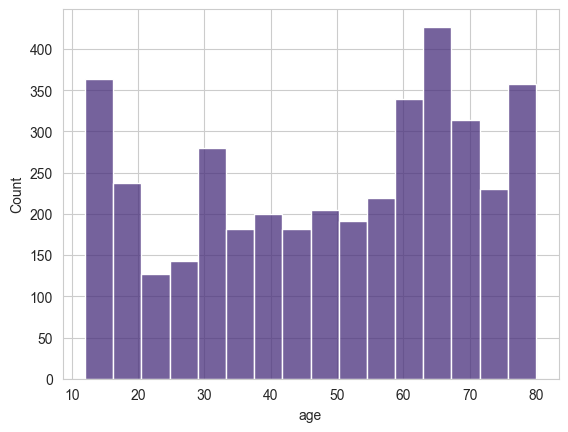

In [63]:
sns.histplot(x='age', data=df)
plt.show()

Individual variables relationship are studied with all data available for that particular variable, therefore missing values are handled only at this point

In [86]:
df_estr = df[['gender', 'age', 'estr']].dropna()
df_estr.isna().sum()

gender    0
age       0
estr      0
dtype: int64

### Estradiol

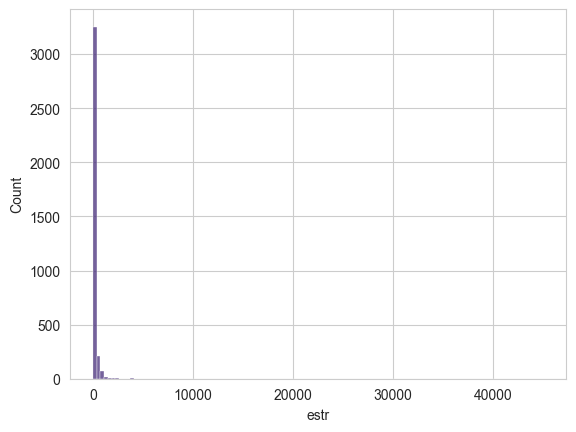

In [87]:
sns.histplot(x='estr', data=df_estr)
plt.show()

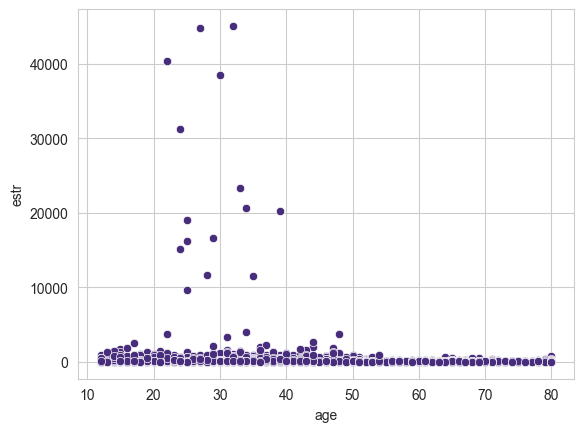

In [88]:
sns.scatterplot(x='age', y='estr', data=df_estr)
plt.show()

In [93]:
sf = df_estr['estr'].quantile(0.75)
tf = df_estr['estr'].quantile(0.25)
IQR = sf - tf

upper = sf + (1.5 * IQR)
lower = tf - (1.5 * IQR)

print('Length with outliers:', len(df_estr))
print('Deleted:', len(df_estr[(df_estr['estr'] < lower) | (df_estr['estr'] > upper)]))
df_estr_no_outliers = df_estr[(df_estr['estr'] > lower) & (df_estr['estr'] < upper)]

Length with outliers: 3585
Deleted: 435


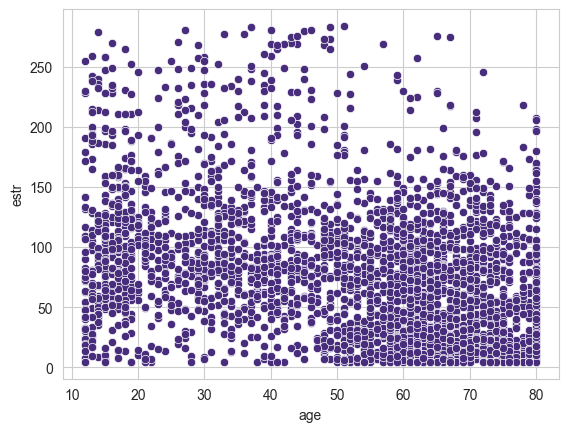

In [95]:
sns.scatterplot(x='age', y='estr', data=df_estr_no_outliers)
plt.show()